# **1. Import Libraries**

In [157]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# **2. Load Dataset**

In [158]:
df=pd.read_csv("/kaggle/input/students-performance-in-exams/StudentsPerformance.csv")

# **3. Dataset Overview**

In [159]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [160]:
df.shape

(1000, 8)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [162]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [163]:
df.count()

gender                         1000
race/ethnicity                 1000
parental level of education    1000
lunch                          1000
test preparation course        1000
math score                     1000
reading score                  1000
writing score                  1000
dtype: int64

In [164]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [165]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [166]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [167]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [168]:
df['reading score'].value_counts()

reading score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
32     1
28     1
23     1
Name: count, Length: 72, dtype: int64

In [169]:
df['writing score'].value_counts()

writing score
74    35
70    33
68    31
73    28
80    27
      ..
22     1
10     1
15     1
30     1
23     1
Name: count, Length: 77, dtype: int64

# **4. 4. Data Preprocessing and Cleaning**

## Check the duplicate values 

In [170]:
df.duplicated().sum()

0

## Handling Missing Values 

In [171]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Feature Engineering 

In [172]:
df['total_marks']= df['math score']+df['reading score']+df['writing score']
df['total_marks']

0      218
1      247
2      278
3      148
4      229
      ... 
995    282
996    172
997    195
998    223
999    249
Name: total_marks, Length: 1000, dtype: int64

In [173]:
df['percentage']=df['total_marks']/300*100
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_marks,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [174]:
df['grade'] = pd.cut(df['percentage'],
                     bins=[0, 50, 65, 80, 100],
                     labels=['Fail', 'Average', 'Good', 'Excellent'])

In [175]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_marks,percentage,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Fail
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Good
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333,Average
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000,Average
998,female,group D,some college,standard,completed,68,78,77,223,74.333333,Good


## Feature Type Identification 

In [176]:
numerical=df.select_dtypes(include=np.number).columns
print("Numerical:",numerical)

Numerical: Index(['math score', 'reading score', 'writing score', 'total_marks',
       'percentage'],
      dtype='object')


In [177]:
categorical=df.select_dtypes(include=object).columns
print("Categorical:",categorical)

Categorical: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


# **5. EDA**

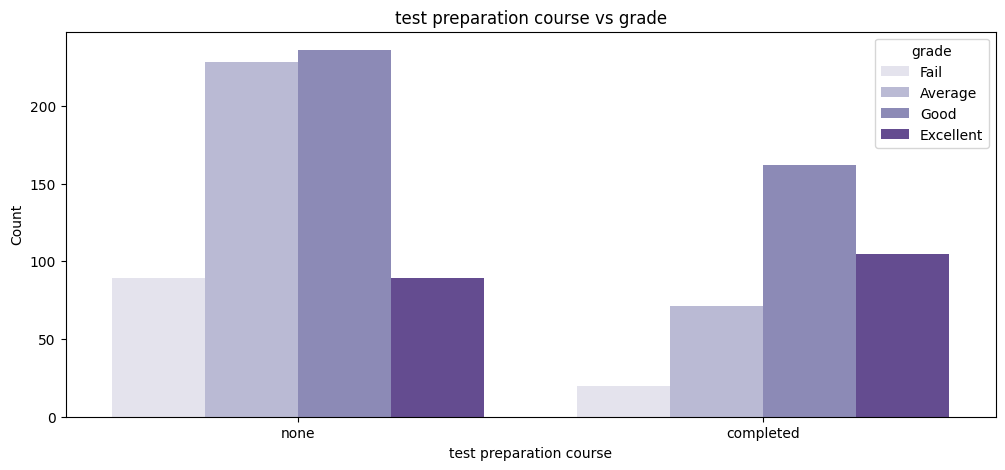

In [178]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x='test preparation course',
    hue='grade',
    data=df,
    palette='Purples'
)
plt.title('test preparation course vs grade')
plt.xlabel('test preparation course')
plt.ylabel('Count')
plt.show()

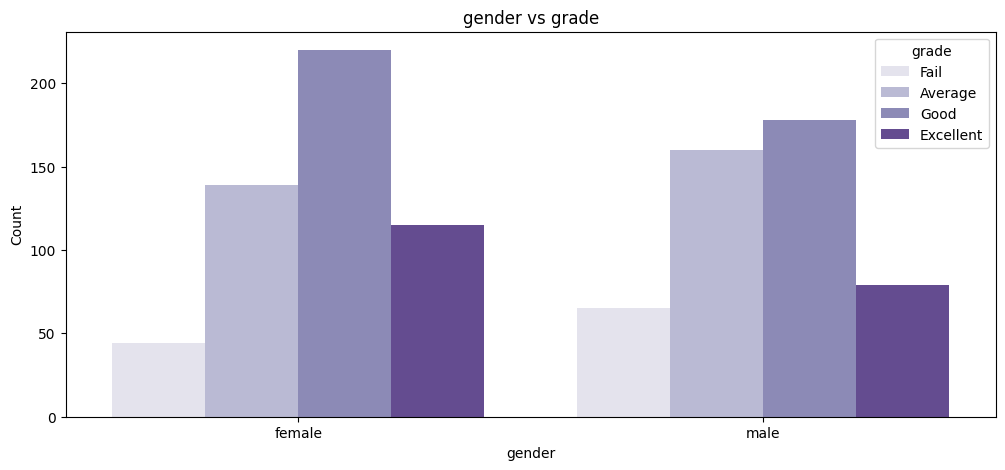

In [179]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x='gender',
    hue='grade',
    data=df,
    palette='Purples'
)
plt.title('gender vs grade')
plt.xlabel('gender')
plt.ylabel('Count')
plt.show()

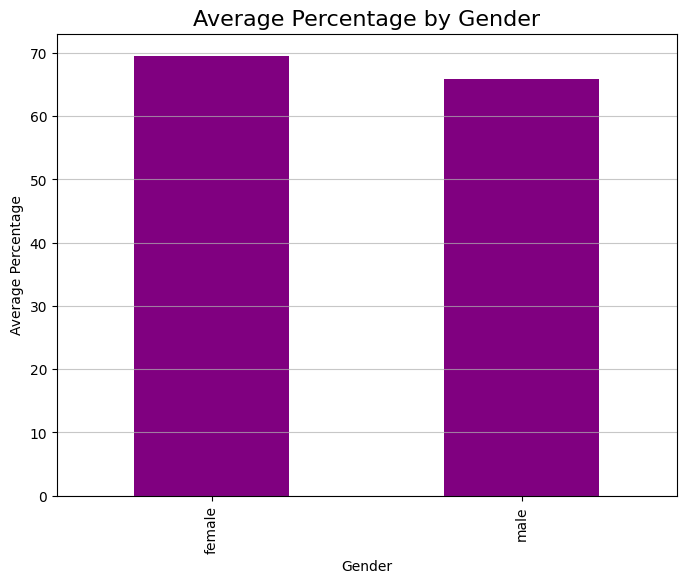

In [180]:
df.groupby('gender')['percentage'].mean().plot(
    kind='bar',
    color='purple',
    figsize=(8,6)
)

plt.title('Average Percentage by Gender', fontsize=16,)
plt.xlabel('Gender')
plt.ylabel('Average Percentage')
plt.grid(axis='y', alpha=0.7)
plt.show()

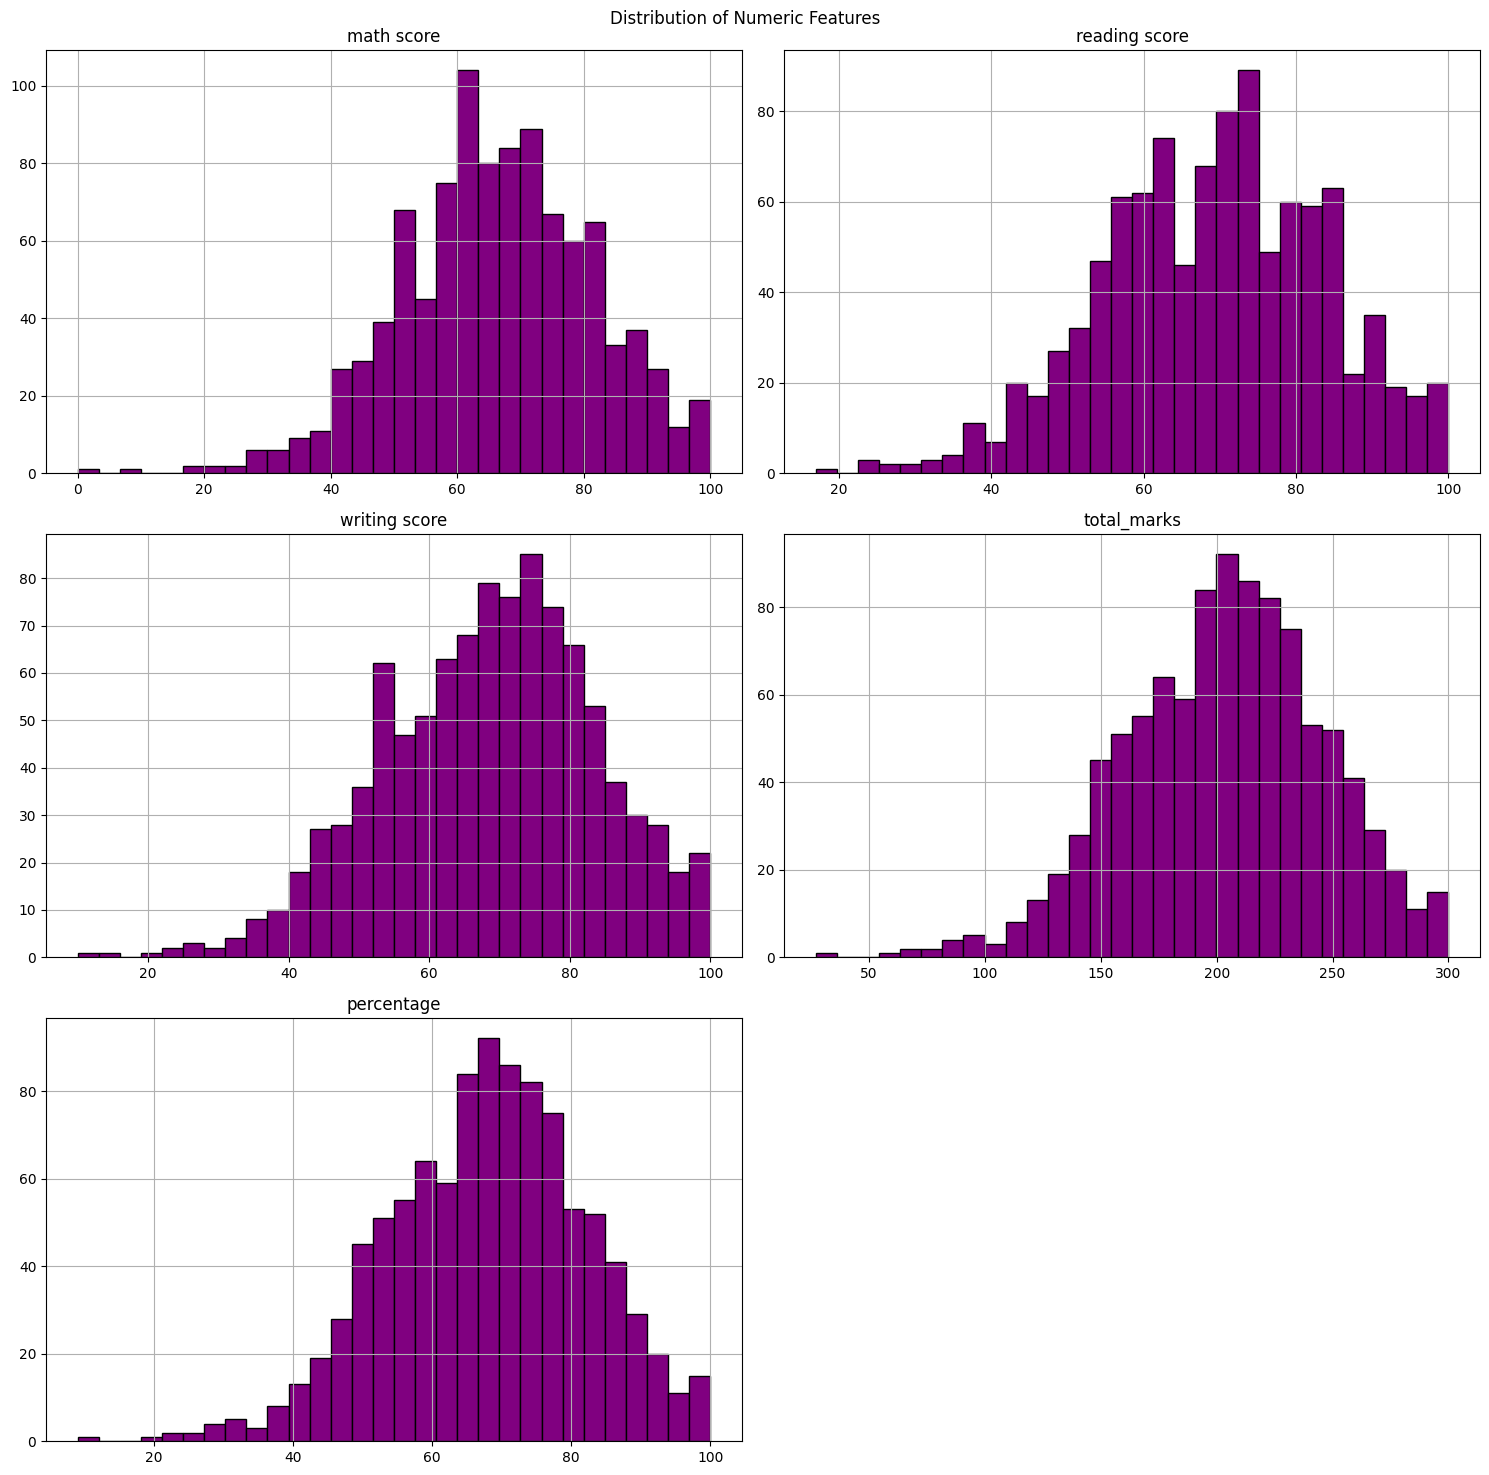

In [181]:
df.hist(color='purple',figsize=(15,15),bins=30,edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

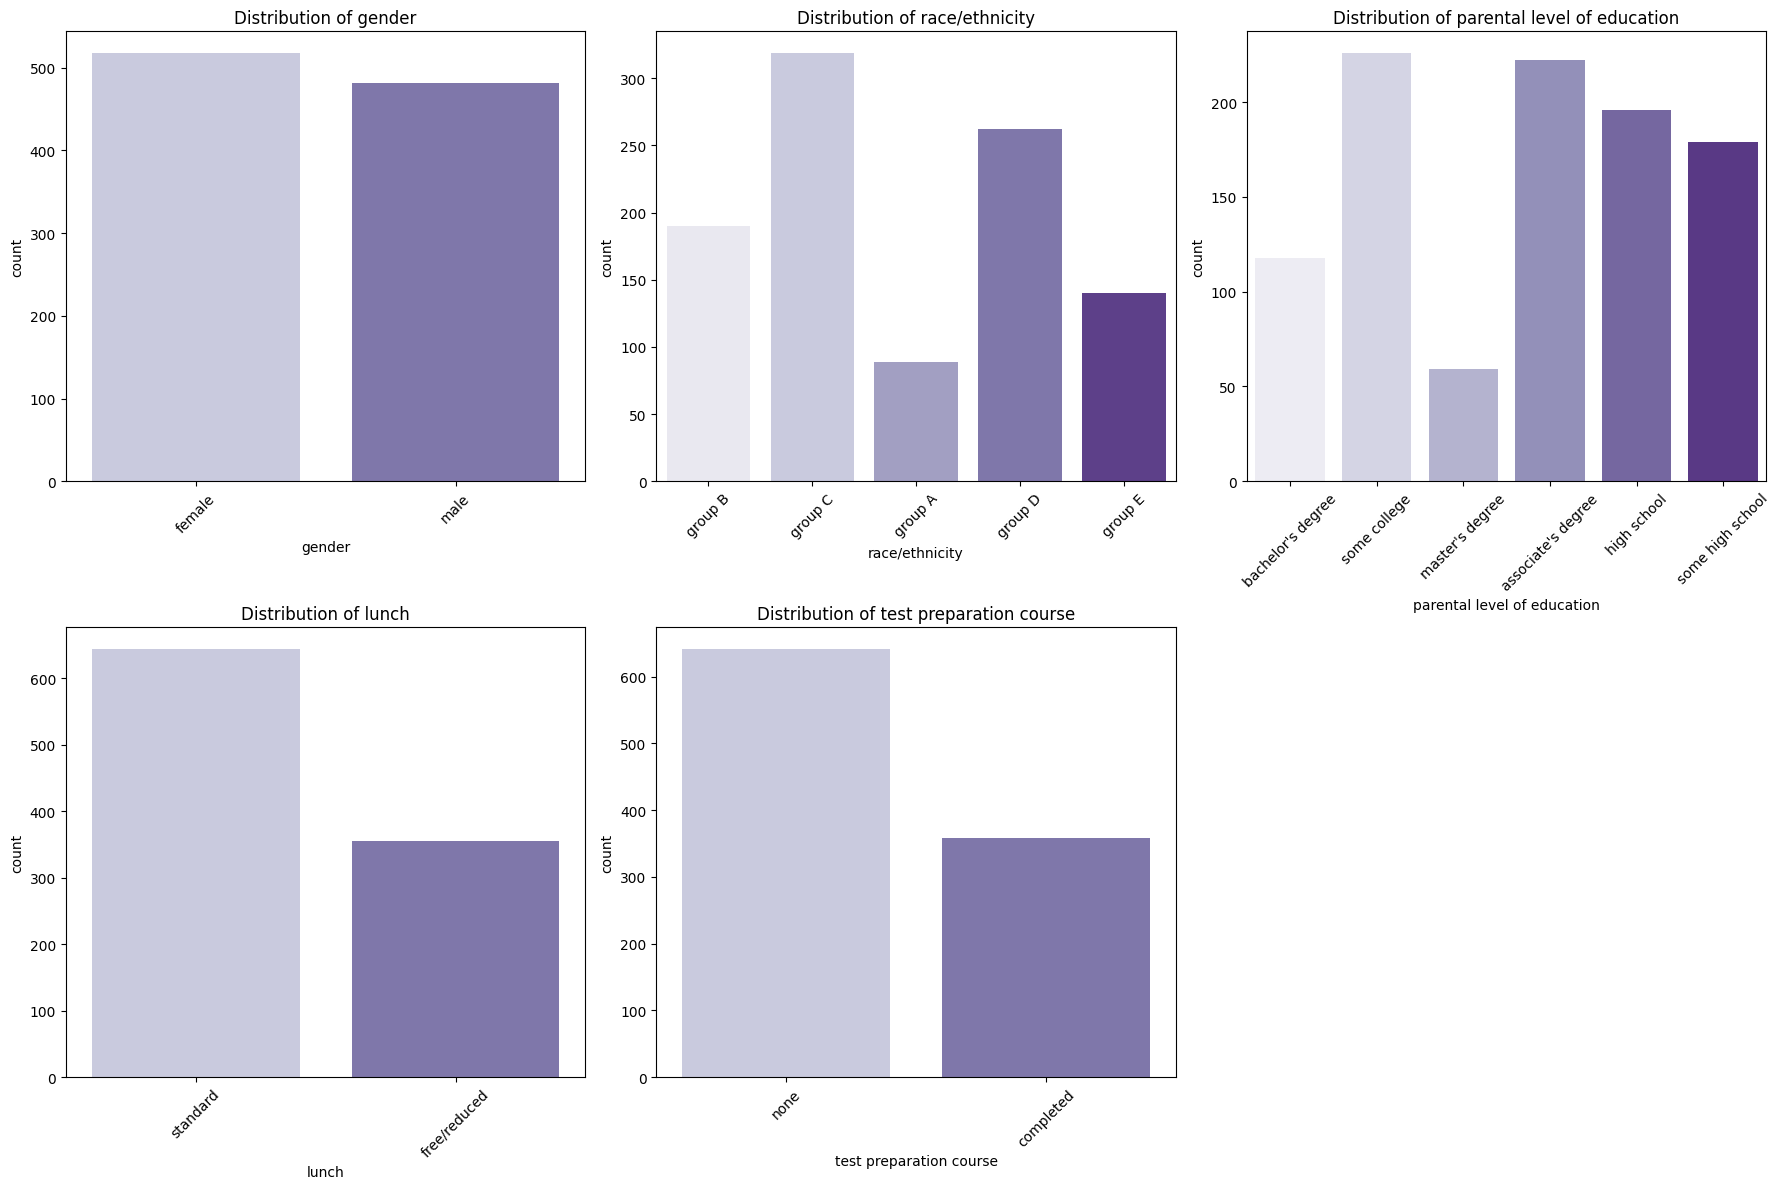

In [182]:

categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot((len(categorical_cols) + 2) // 3, 3, i)
    sns.countplot(data=df, x=col, palette='Purples')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



## Outlier Detection

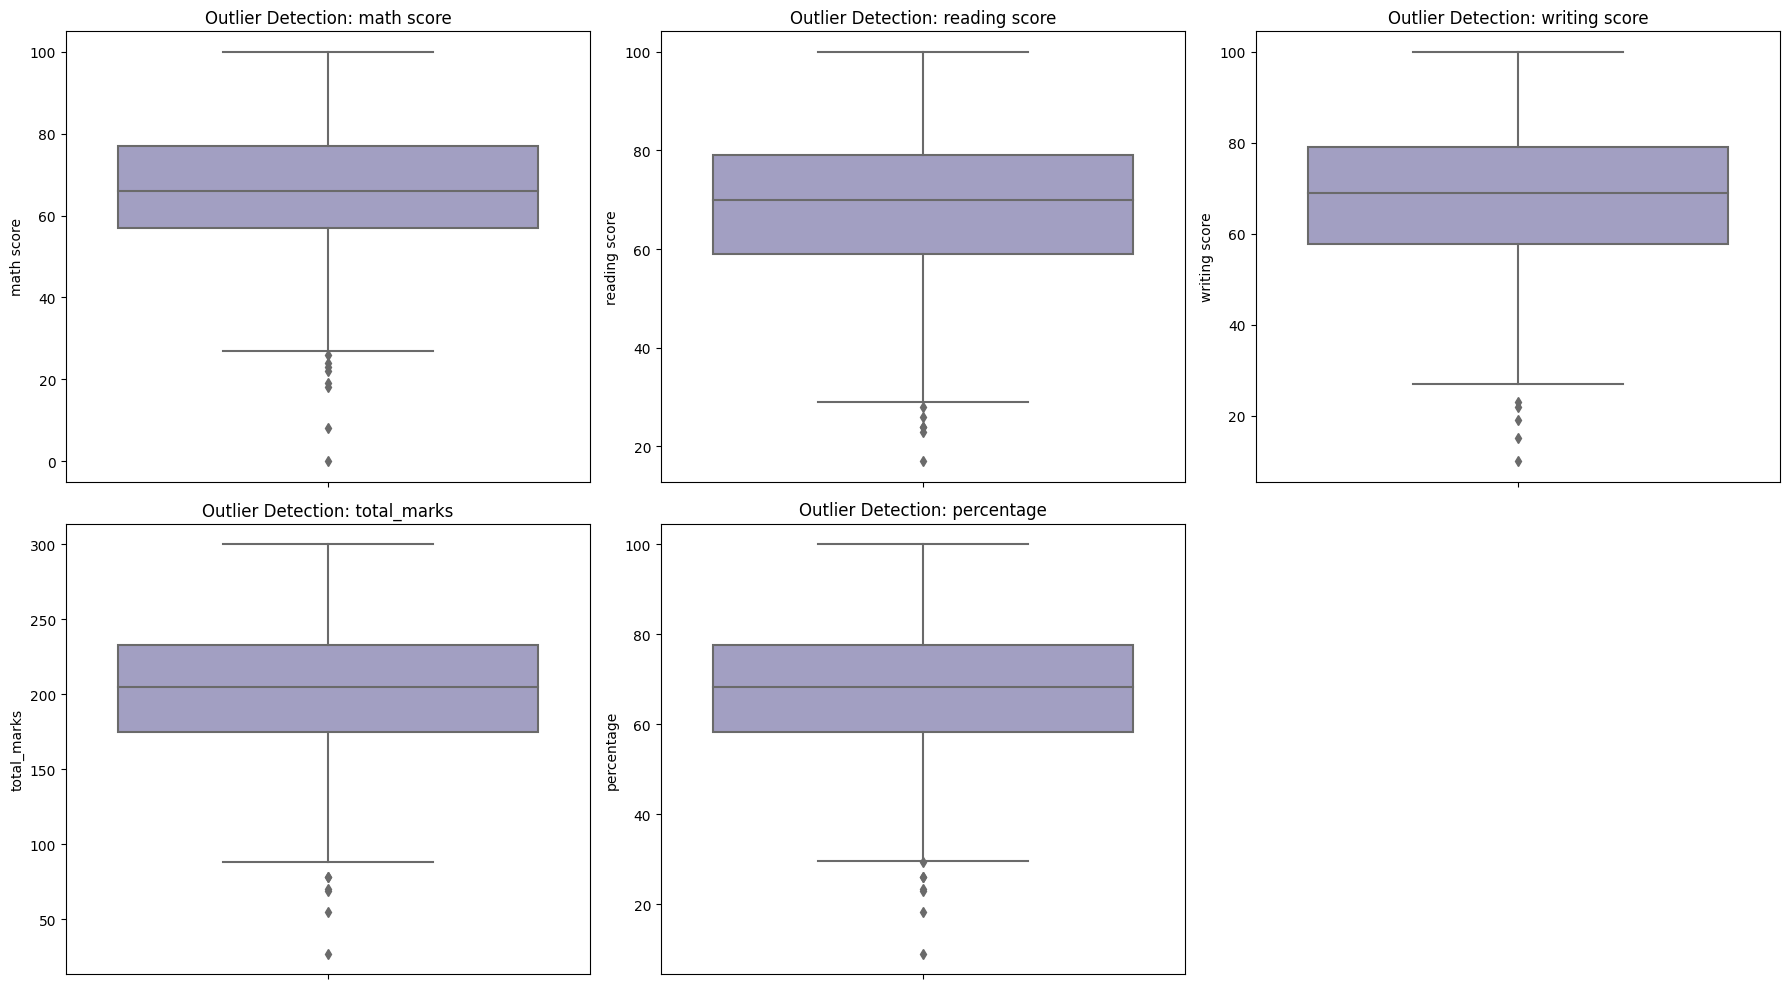

In [183]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, i)
    sns.boxplot(y=df[col], palette='Purples')
    plt.title(f'Outlier Detection: {col}')

plt.tight_layout()
plt.show()

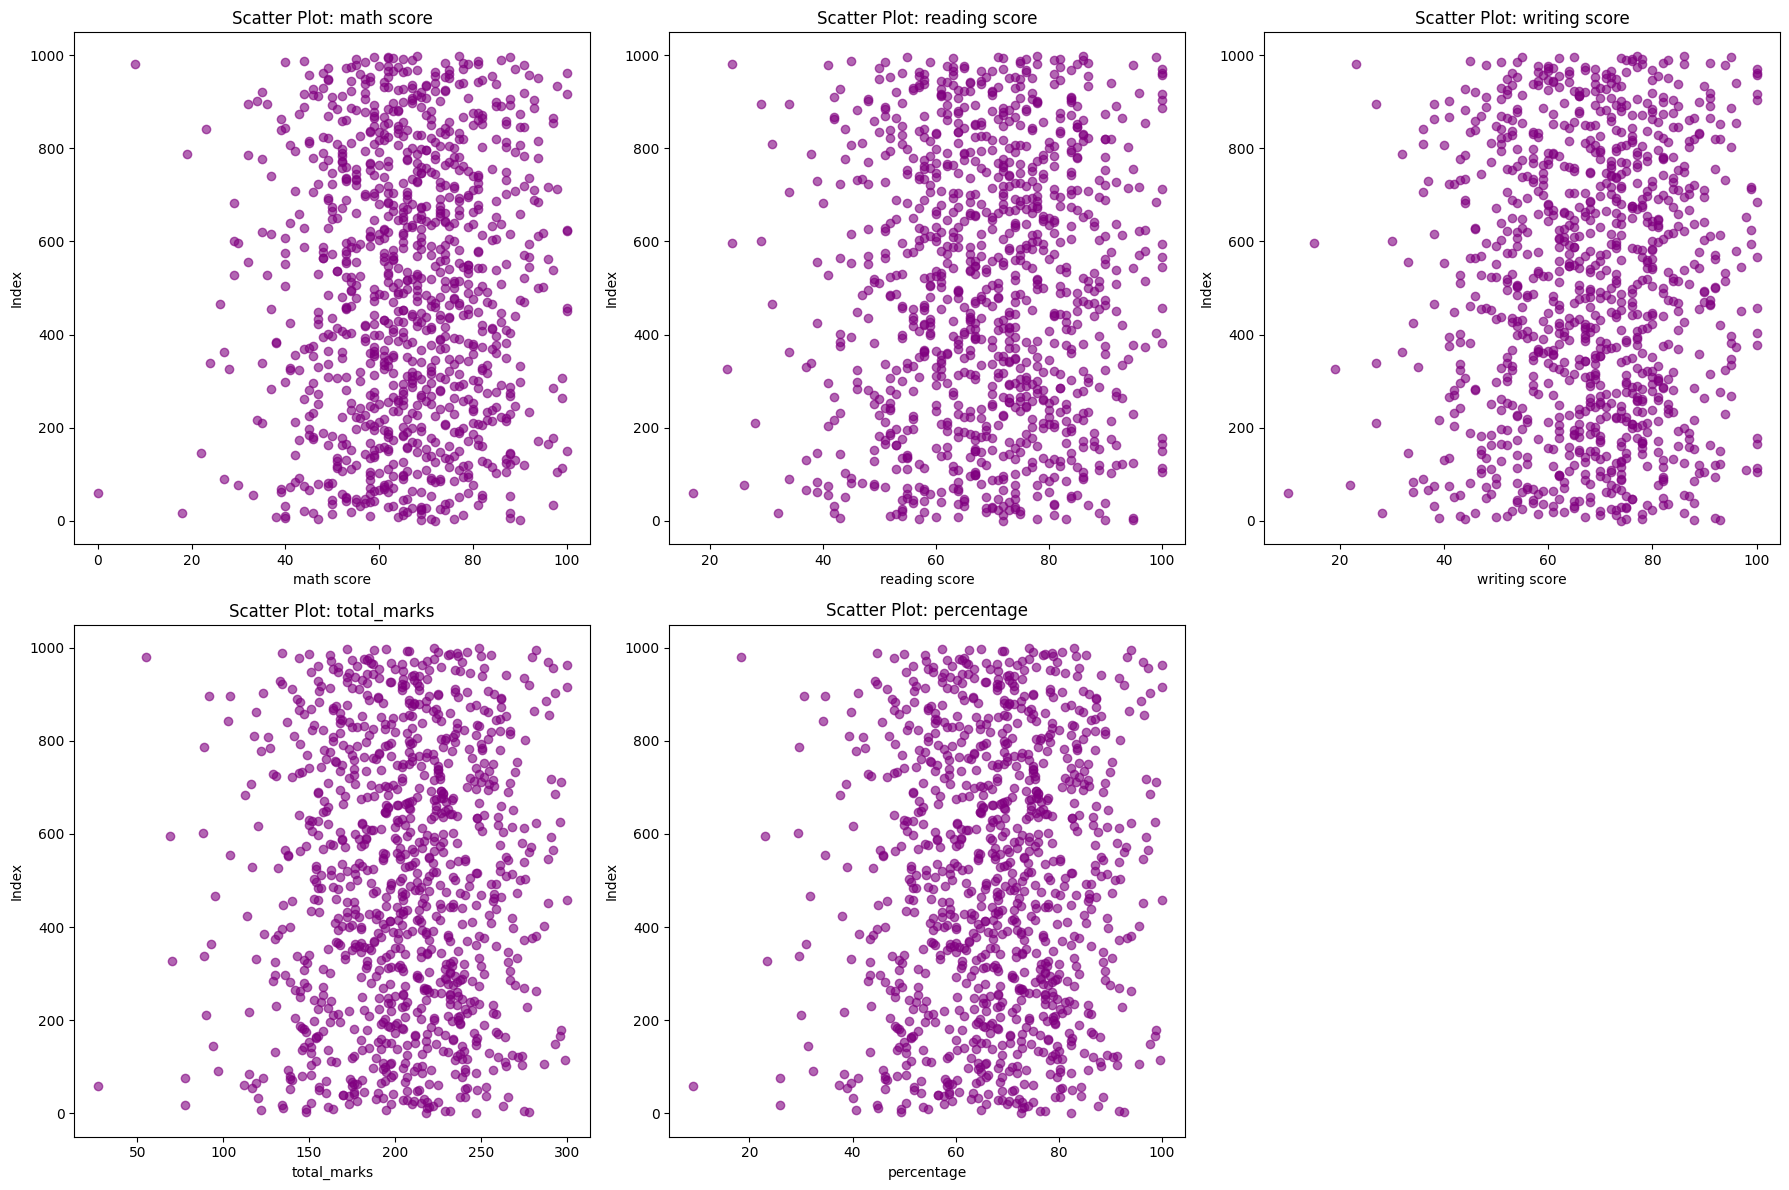

In [184]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, i)
    plt.scatter(df[col], df.index, color='purple', alpha=0.6)
    plt.title(f'Scatter Plot: {col}')
    plt.xlabel(col)
    plt.ylabel('Index')

plt.tight_layout()
plt.show()

# **6. Feature–Target Separation**

In [185]:
X = df.drop(['percentage', 'total_marks', 'grade'], axis=1)
y = df['grade']

# **7. One Hot Encoing**

In [186]:
X = pd.get_dummies(X, drop_first=True)

# **8. Label Encoding**

'Fail' → 0

'Average' → 1

'Good' → 2

'Excellent' → 3

In [187]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Transform target labels to numeric
y_encoded = le.fit_transform(y)

# Now y_encoded can be used to train models
print("Original labels:", y.unique())
print("Encoded labels:", y_encoded)


Original labels: ['Good', 'Excellent', 'Fail', 'Average']
Categories (4, object): ['Fail' < 'Average' < 'Good' < 'Excellent']
Encoded labels: [3 1 1 2 3 3 1 2 0 2 0 2 3 3 0 3 1 2 2 0 3 3 0 3 3 3 0 3 3 3 3 0 0 2 1 1 3
 0 1 0 0 3 0 0 0 0 0 3 3 1 0 3 2 1 1 2 1 0 0 2 3 2 0 3 0 0 2 3 0 0 0 0 2 0
 2 2 2 3 3 3 2 2 0 3 2 3 1 3 0 1 3 2 3 2 1 1 0 3 0 0 3 3 1 0 1 3 1 0 3 3 1
 0 0 0 1 3 1 3 0 0 1 1 1 0 3 1 3 3 3 0 1 2 3 3 3 0 2 0 0 3 3 0 0 2 3 2 1 3
 3 1 3 3 0 2 0 1 3 0 3 0 3 1 0 0 1 1 0 3 3 3 3 1 1 3 2 1 0 3 0 1 3 0 2 3 2
 3 3 3 2 1 3 3 0 3 3 0 0 0 0 3 3 3 3 0 2 3 3 3 3 0 3 2 0 0 1 1 1 2 3 0 3 1
 0 1 0 0 3 0 3 1 3 2 3 1 1 3 3 3 0 1 3 1 0 0 3 3 3 3 0 0 2 3 3 3 0 3 3 3 3
 3 3 3 2 1 3 2 3 3 1 3 0 2 0 3 1 3 1 3 3 0 2 2 3 3 2 1 1 3 3 3 3 3 0 3 3 0
 2 3 2 1 3 0 3 3 3 3 1 2 0 0 3 0 3 3 3 3 1 3 3 0 3 3 3 2 2 1 0 2 3 2 0 2 0
 1 1 0 3 2 2 2 0 3 3 3 3 3 0 1 3 3 0 0 3 0 3 3 0 0 0 1 0 1 0 2 0 0 0 0 0 1
 3 0 3 1 3 2 1 1 3 0 1 1 3 2 2 3 3 3 0 3 3 3 3 0 3 2 0 1 0 0 0 2 0 1 0 3 0
 3 0 1 3 1 3 3 3 3 3 3 0 0 1 0 0 

# **9. Train/Test Split**

In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [189]:
X_train.shape

(800, 15)

In [190]:
X_test.shape

(200, 15)

# **10. Models Definition**

In [191]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', C=1.0),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=10),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.5),
    "Bagging Classifier": BaggingClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200)
}

# **11. Model Training, Prediction and Evaluation**

In [192]:
# Train and evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train using encoded target
    y_pred = model.predict(X_test)  # Predict
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("-" * 50)

Logistic Regression Accuracy: 0.8750
              precision    recall  f1-score   support

     Average       0.86      0.82      0.84        60
   Excellent       0.95      0.90      0.92        39
        Fail       1.00      0.64      0.78        22
        Good       0.84      0.97      0.90        79

    accuracy                           0.88       200
   macro avg       0.91      0.83      0.86       200
weighted avg       0.88      0.88      0.87       200

--------------------------------------------------
Random Forest Accuracy: 0.9450
              precision    recall  f1-score   support

     Average       0.93      0.92      0.92        60
   Excellent       1.00      0.95      0.97        39
        Fail       0.95      0.91      0.93        22
        Good       0.93      0.97      0.95        79

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200

-----------

# **12. Confusion Matrix**


Logistic Regression Accuracy: 0.8750
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        60
           1       0.95      0.90      0.92        39
           2       1.00      0.64      0.78        22
           3       0.84      0.97      0.90        79

    accuracy                           0.88       200
   macro avg       0.91      0.83      0.86       200
weighted avg       0.88      0.88      0.87       200



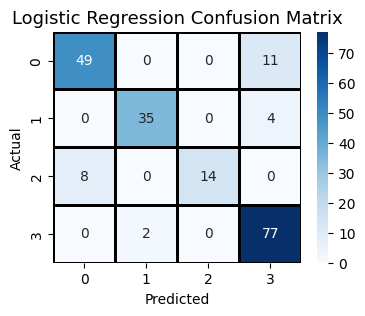

------------------------------------------------------------

Random Forest Accuracy: 0.9450
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        60
           1       1.00      0.95      0.97        39
           2       0.95      0.91      0.93        22
           3       0.93      0.97      0.95        79

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



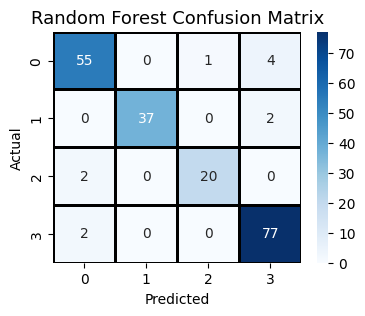

------------------------------------------------------------

Support Vector Machine Accuracy: 0.9150
              precision    recall  f1-score   support

           0       0.86      0.92      0.89        60
           1       1.00      0.92      0.96        39
           2       1.00      0.59      0.74        22
           3       0.91      1.00      0.95        79

    accuracy                           0.92       200
   macro avg       0.94      0.86      0.89       200
weighted avg       0.92      0.92      0.91       200



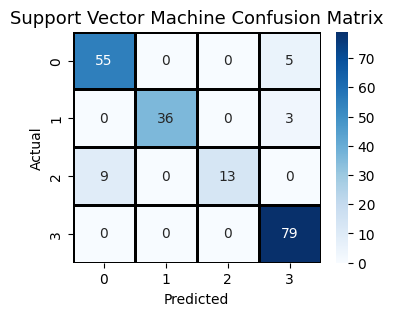

------------------------------------------------------------

Decision Tree Accuracy: 0.9250
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        60
           1       0.97      0.92      0.95        39
           2       0.86      0.86      0.86        22
           3       0.94      0.95      0.94        79

    accuracy                           0.93       200
   macro avg       0.92      0.91      0.92       200
weighted avg       0.93      0.93      0.93       200



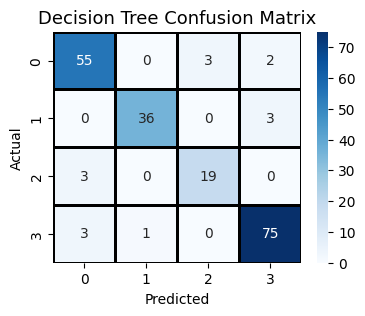

------------------------------------------------------------

K-Nearest Neighbors Accuracy: 0.9800
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        60
           1       1.00      1.00      1.00        39
           2       1.00      0.95      0.98        22
           3       0.97      0.99      0.98        79

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



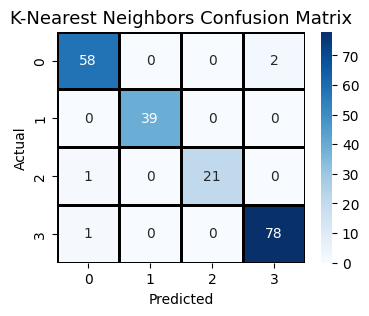

------------------------------------------------------------

Naive Bayes Accuracy: 0.9400
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        60
           1       0.97      0.95      0.96        39
           2       0.95      0.95      0.95        22
           3       0.93      0.95      0.94        79

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



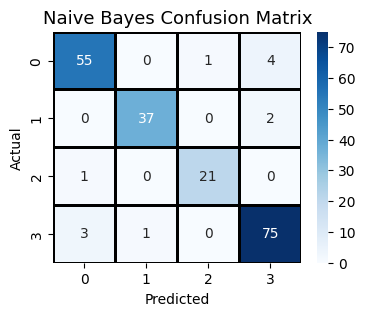

------------------------------------------------------------

Gradient Boosting Accuracy: 0.9600
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        60
           1       1.00      0.97      0.99        39
           2       1.00      0.86      0.93        22
           3       0.96      0.97      0.97        79

    accuracy                           0.96       200
   macro avg       0.97      0.94      0.96       200
weighted avg       0.96      0.96      0.96       200



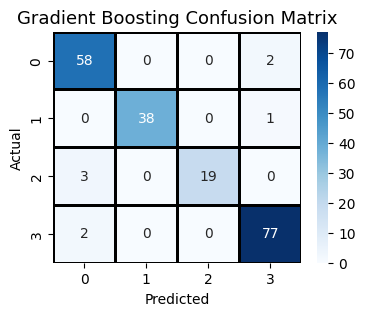

------------------------------------------------------------

AdaBoost Accuracy: 0.7900
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        60
           1       1.00      0.41      0.58        39
           2       1.00      0.36      0.53        22
           3       0.74      0.99      0.85        79

    accuracy                           0.79       200
   macro avg       0.88      0.67      0.70       200
weighted avg       0.84      0.79      0.76       200



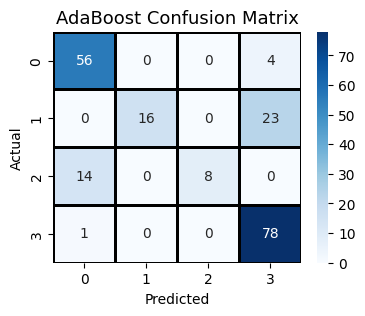

------------------------------------------------------------

Bagging Classifier Accuracy: 0.9350
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        60
           1       1.00      0.95      0.97        39
           2       0.95      0.82      0.88        22
           3       0.93      0.97      0.95        79

    accuracy                           0.94       200
   macro avg       0.94      0.91      0.93       200
weighted avg       0.94      0.94      0.93       200



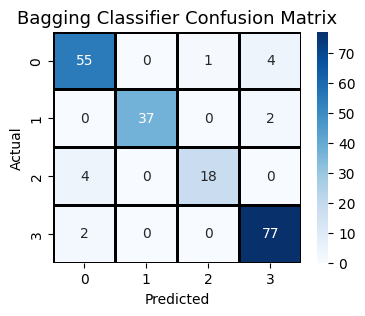

------------------------------------------------------------

XGBoost Accuracy: 0.9600
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        60
           1       1.00      0.97      0.99        39
           2       1.00      0.82      0.90        22
           3       0.97      0.97      0.97        79

    accuracy                           0.96       200
   macro avg       0.97      0.94      0.95       200
weighted avg       0.96      0.96      0.96       200



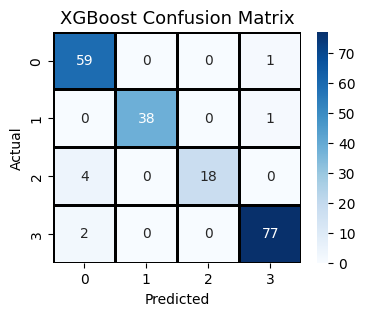

------------------------------------------------------------


In [193]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=2,
        linecolor="k"
    )
    
    plt.title(f"{name} Confusion Matrix", fontsize=13)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    print("-" * 60)

# **13. Model Performance Comparison**

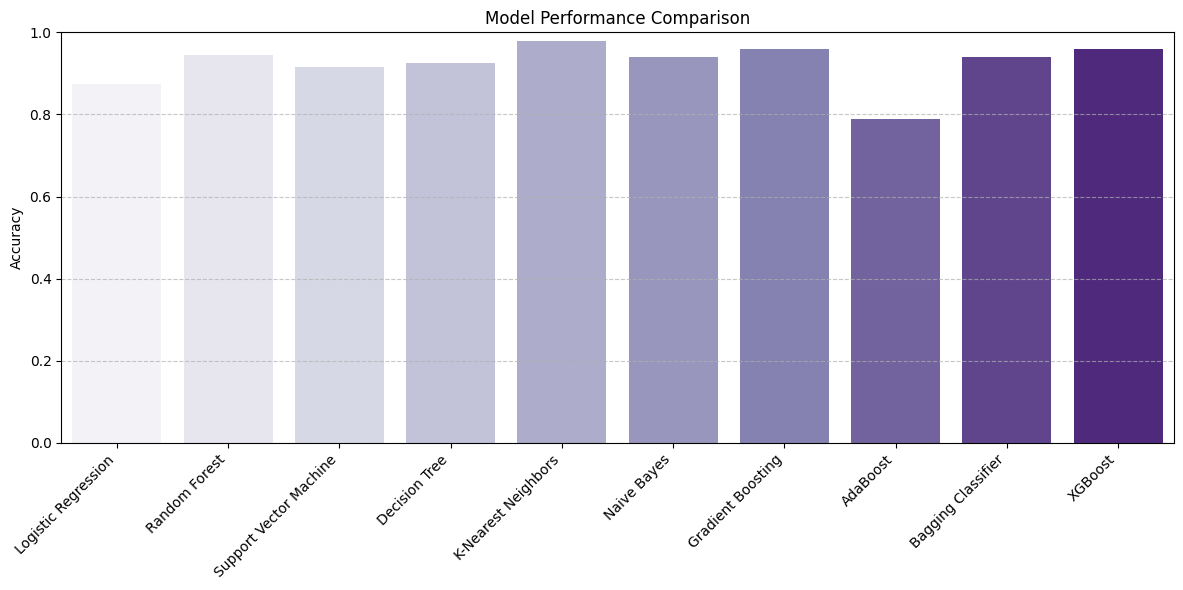

In [194]:
plt.figure(figsize=(12, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Purples")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # optional: scale y-axis from 0 to 1
plt.title("Model Performance Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **14. Saving Model**

In [195]:
import joblib
import os

In [196]:
os.makedirs("saved_models", exist_ok=True)

In [197]:
# Create folder once
os.makedirs("saved_models", exist_ok=True)

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)


    # SAVE MODEL
    model_filename = f"saved_models/{name.replace(' ', '_')}.joblib"
    joblib.dump(model, model_filename)

    print(f"Model saved as: {model_filename}")
    print("-" * 60)

Model saved as: saved_models/Logistic_Regression.joblib
------------------------------------------------------------
Model saved as: saved_models/Random_Forest.joblib
------------------------------------------------------------
Model saved as: saved_models/Support_Vector_Machine.joblib
------------------------------------------------------------
Model saved as: saved_models/Decision_Tree.joblib
------------------------------------------------------------
Model saved as: saved_models/K-Nearest_Neighbors.joblib
------------------------------------------------------------
Model saved as: saved_models/Naive_Bayes.joblib
------------------------------------------------------------
Model saved as: saved_models/Gradient_Boosting.joblib
------------------------------------------------------------
Model saved as: saved_models/AdaBoost.joblib
------------------------------------------------------------
Model saved as: saved_models/Bagging_Classifier.joblib
---------------------------------------